# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40 # do not change this value
np.random.seed(seed)

load the data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # summarize missing-value columns before imputation
    missing_cols = [col for col in feature_cols if df[col].isna().any()]
    summary_records = []
    for col in missing_cols:
        summary_records.append({
            'column': col,
            'missing_count': int(df[col].isna().sum()),
            'median_before': df[col].median(),
            'std_before': df[col].std(),
        })

    # Replace the missing values using Nearest Neighbors Imputation
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    # summarize the same columns after imputation
    for record in summary_records:
        col = record['column']
        record['median_after'] = df[col].median()
        record['std_after'] = df[col].std()
        record['median_delta'] = record['median_after'] - record['median_before']
        record['std_delta'] = record['std_after'] - record['std_before']

    summary_cols = [
        'column',
        'missing_count',
        'median_before',
        'std_before',
        'median_after',
        'std_after',
        'median_delta',
        'std_delta',
    ]
    summary_df = pd.DataFrame(summary_records, columns=summary_cols)

    metrics_dir = Path('result/metrics')
    metrics_dir.mkdir(parents=True, exist_ok=True)
    summary_path_csv = metrics_dir / 'real_world_missing_value_summary.csv'
    summary_df.to_csv(summary_path_csv, index=False)

    print('Missing-value summary saved to:')
    print(summary_path_csv)
    display(summary_df)

    return df, feature_cols

df, feature_cols = data_preprocessing(df)

Missing-value summary saved to:
result\metrics\real_world_missing_value_summary.csv


,column,missing_count,median_before,std_before,median_after,std_after,median_delta,std_delta
0,SepalLengthCm,28,6.300000,1.037115,6.300000,1.009275,0.000000,-0.027840
1,SepalWidthCm,57,2.900000,0.389564,2.900000,0.372434,0.000000,-0.017130
2,PetalLengthCm,150,5.085612,1.582807,5.035683,1.514955,-0.049928,-0.067853
3,PetalWidthCm,22,1.600000,0.706689,1.700000,0.694645,0.100000,-0.012044
4,BranchLength,24,16.300000,1.035228,16.300000,1.011012,0.000000,-0.024215


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

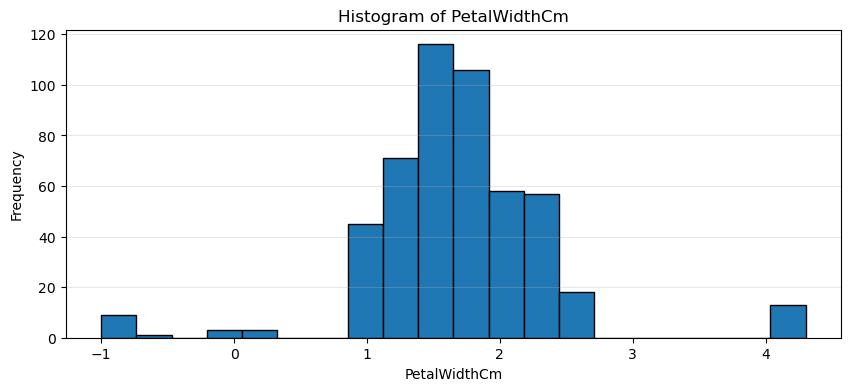

b. Feature with largest positive correlation with PetalWidthCm:
   PetalWidthCompactness: 0.9917

c. Top 5 features with strongest negative correlations with PetalWidthCm:
   PetalThicknessIndex: -0.0033
   FloralSymmetryScore: -0.0036
   LeafHueVariation: -0.0038
   IrisPigmentGranularity: -0.0041
   IrisVenationDepth: -0.0043


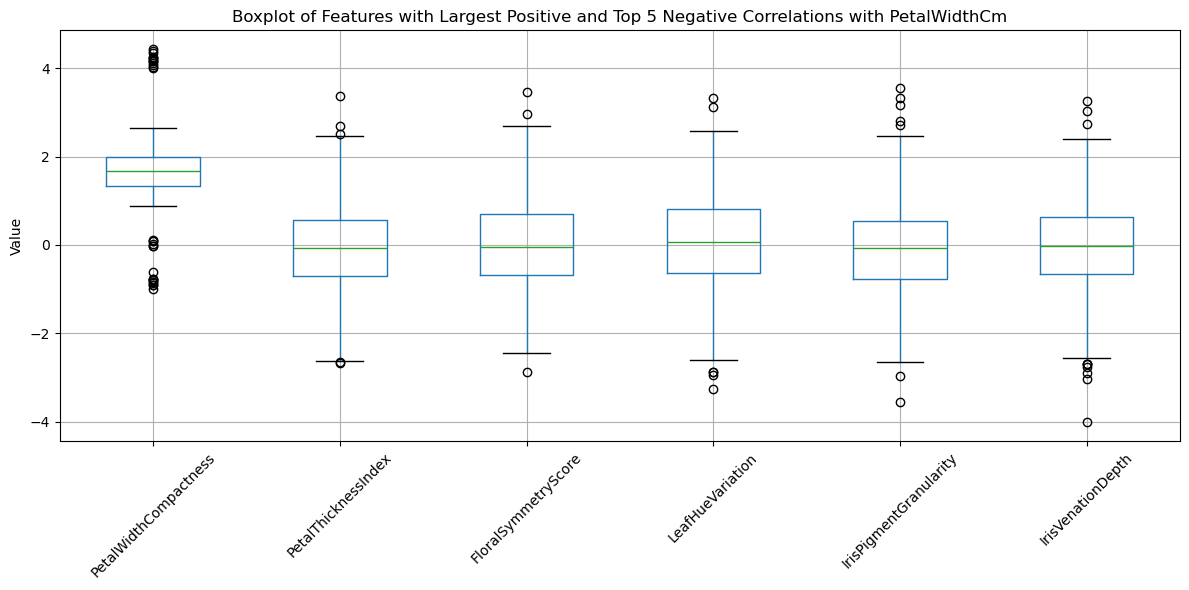

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# a. Plot histogram of PetalWidthCm
plt.figure(figsize=(10, 4))
plt.hist(df['PetalWidthCm'], bins=20, edgecolor='black')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.title('Histogram of PetalWidthCm')
plt.grid(axis='y', alpha=0.3)
plt.show()

# b. Find feature with largest positive correlation with PetalWidthCm
target = 'PetalWidthCm'
exclude_cols = {'PetalWidthCm', 'Species', 'Id'}
candidate_cols = [c for c in feature_cols if c not in exclude_cols]

correlations = {}
for col in candidate_cols:
    corr, _ = pearsonr(df[col], df[target])
    correlations[col] = corr

# Sort by correlation descending
sorted_corr = sorted(correlations.items(), key=lambda x: x[1], reverse=True)
max_positive_corr_feature = sorted_corr[0][0]
max_positive_corr_value = sorted_corr[0][1]

print(f"b. Feature with largest positive correlation with {target}:")
print(f"   {max_positive_corr_feature}: {max_positive_corr_value:.4f}")

# c. Report top 5 features with strongest negative correlations
negative_corr = [(col, corr) for col, corr in sorted_corr if corr < 0]
top_5_negative = negative_corr[:5] if len(negative_corr) >= 5 else negative_corr

print(f"\nc. Top 5 features with strongest negative correlations with {target}:")
for col, corr in top_5_negative:
    print(f"   {col}: {corr:.4f}")

# d. Plot boxplot for features from b) and c)
boxplot_features = [max_positive_corr_feature] + [col for col, _ in top_5_negative]
boxplot_data = df[boxplot_features]

plt.figure(figsize=(12, 6))
boxplot_data.boxplot()
plt.ylabel('Value')
plt.title('Boxplot of Features with Largest Positive and Top 5 Negative Correlations with PetalWidthCm')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [6]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
df.head()

Train shape: (350, 70) | Test shape: (150, 70)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6183886535310102, Val loss:0.6383381911771241
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177572
200. Training loss: 0.5636439627476499, Val loss:0.6019785825360592
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.5889917649142379
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.5127496761323889, Val loss:0.5755614147648993
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121452
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.5712595149307161
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860385
750. Training loss: 0.49152377948438897, Val los

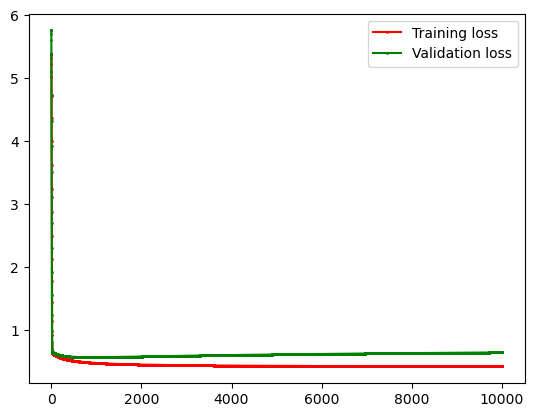

no_regularization: last_train_loss=0.422306, last_val_loss=0.645646
50. Training loss: 0.6183968442308057, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988916
150. Training loss: 0.5781987940557217, Val loss:0.6111917862872271
200. Training loss: 0.5636852669117253, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456719, Val loss:0.5947528491389577
300. Training loss: 0.5414760921827048, Val loss:0.5890110215795247
350. Training loss: 0.5327814781753895, Val loss:0.584438157145108
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412457
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950174
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452543
550. Training loss: 0.5076902593666242, Val loss:0.57375533358103
600. Training loss: 0.5030625328026356, Val loss:0.5723389483402412
650. Training loss: 0.4988935840888995, Val loss:0.5712557548145529
700. Training loss: 0.4951176496280415, Val loss:0.5

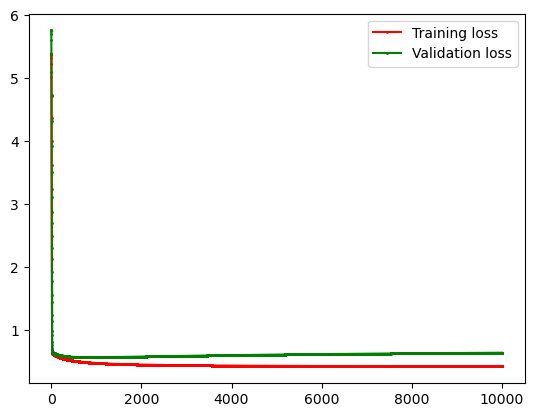

l2_lambda_0.01: last_train_loss=0.422975, last_val_loss=0.641281
50. Training loss: 0.6192229675550639, Val loss:0.6387339171797571
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.6126225576568589
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908267
250. Training loss: 0.5571858255876309, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871132
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798572
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364932
500. Training loss: 0.524460662779445, Val loss:0.5791436781671647
550. Training loss: 0.5204280628046019, Val loss:0.5773422515546591
600. Training loss: 0.5169056942810415, Val loss:0.5758788683267105
650. Training loss: 0.5138115085968704, Val loss:0.57468898760961
700. Training loss: 0.5110797027848409, Val loss:0.573721

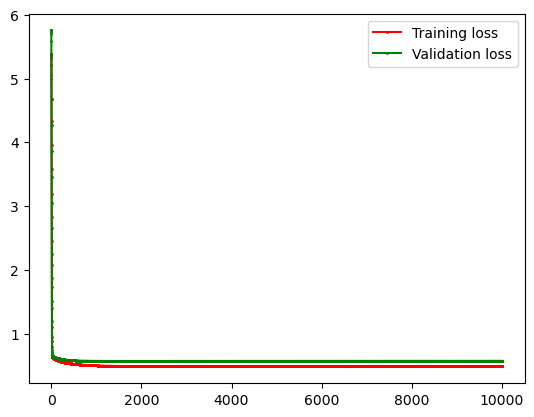

l2_lambda_1: last_train_loss=0.483775, last_val_loss=0.571960
50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460088
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828774, Val loss:0.6839298554692588
400. Training loss: 0.674748717982937, Val loss:0.6839298554693629
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298

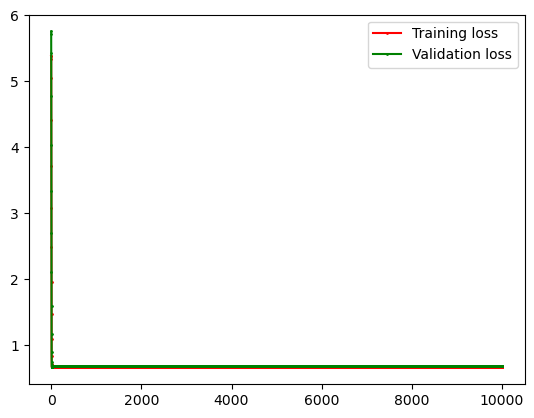

l2_lambda_100: last_train_loss=0.674749, last_val_loss=0.683930


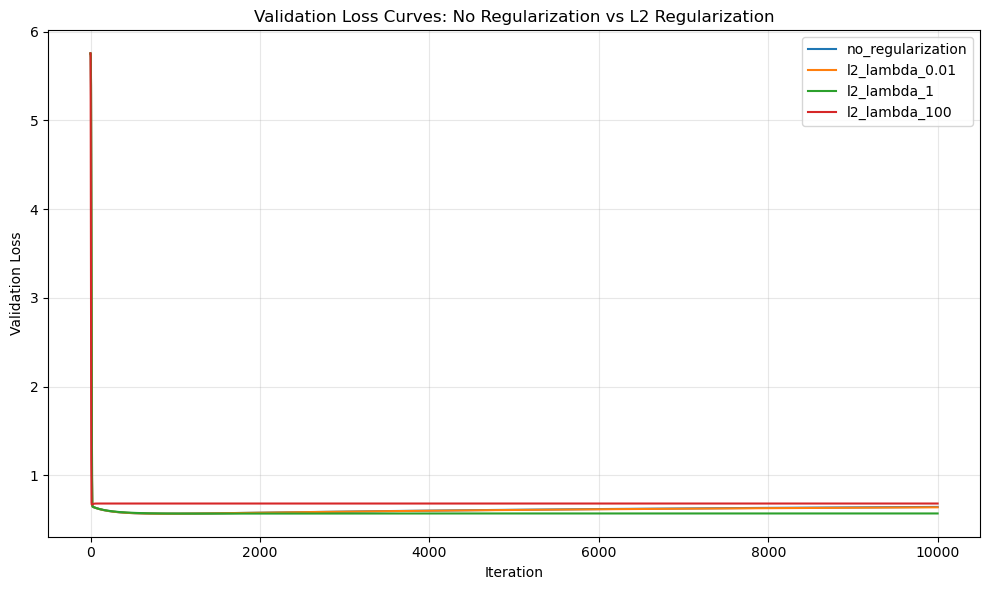

In [8]:
# Train models with and without L2 regularization
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid
import matplotlib.pyplot as plt
import numpy as np

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

settings = [
    {'name': 'no_regularization', 'reg_type': '', 'reg_lambda': 0.0},
    {'name': 'l2_lambda_0.01', 'reg_type': 'l2', 'reg_lambda': 0.01},
    {'name': 'l2_lambda_1', 'reg_type': 'l2', 'reg_lambda': 1.0},
    {'name': 'l2_lambda_100', 'reg_type': 'l2', 'reg_lambda': 100.0},
]

trained_models = {}
training_logs = {}

for cfg in settings:
    np.random.seed(seed)
    model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=loss_fn,
        act_fn=act_fn,
        grad_fn=grad_fn,
    )

    model.fit(
        X_train,
        y_train,
        lr=0.1,
        n_iteration=10000,
        val_ratio=0.2,
        reg_type=cfg['reg_type'],
        reg_lambda=cfg['reg_lambda'],
    )

    trained_models[cfg['name']] = model
    training_logs[cfg['name']] = {
        'train_loss': model.train_losses,
        'val_loss': model.val_losses,
        'config': cfg,
    }

    print(
        f"{cfg['name']}: last_train_loss={model.train_losses[-1]:.6f}, "
        f"last_val_loss={model.val_losses[-1]:.6f}"
    )

# Plot loss curves for all settings (validation loss)
plt.figure(figsize=(10, 6))
for name, log in training_logs.items():
    plt.plot(log['val_loss'], label=name)

plt.title('Validation Loss Curves: No Regularization vs L2 Regularization')
plt.xlabel('Iteration')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Metrics

Testing Result 1: No Regularization
Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


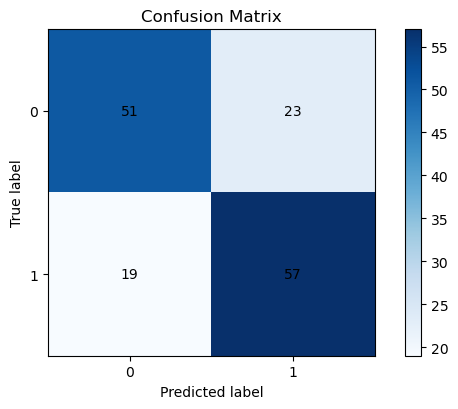


Testing Result 2: L2 Regularization (reg_lambda=1)
Model Evaluation
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


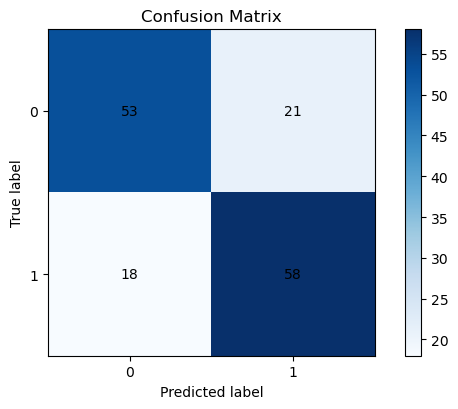

{'Accuracy': 0.74,
 'Precision': 0.7341772151898734,
 'Recall': 0.7631578947368421,
 'F1-score': 0.7483870967741936}

In [9]:
# Evaluate binary classification performance
from model.metrics import evaluate_binary_classifier

print('Testing Result 1: No Regularization')
y_pred_no_reg = trained_models['no_regularization'].predict(X_test)
evaluate_binary_classifier(y_test, y_pred_no_reg)

print('\nTesting Result 2: L2 Regularization (reg_lambda=1)')
y_pred_l2 = trained_models['l2_lambda_1'].predict(X_test)
evaluate_binary_classifier(y_test, y_pred_l2)